<a href="https://colab.research.google.com/github/abdullahnaeem151015-lgtm/ML-pipeline/blob/main/Copy_of_w06_validation_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


The two findings that came from FlyRank's search paper are given below:
**1: Feature importance(What predicts the health):**

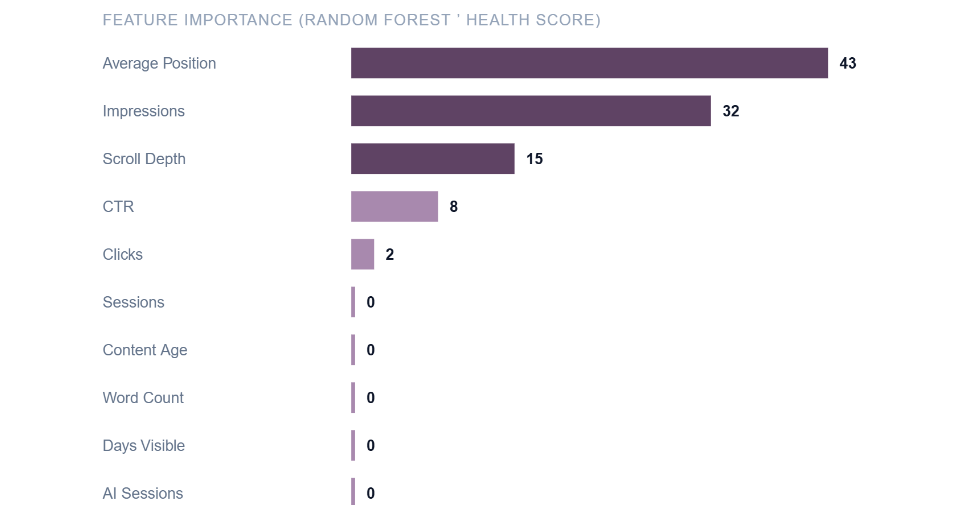

**Label**: The target of each these features is to predict the health score where average position contributes most in it with 43% followed by impressions of 32% and scroll depth, CTR, clicks
**Validation**:: The Random Forest was tested using an 80/20 split, but because some predictors are also used to construct the Health Score, the feature importance should be treated as descriptive rather than causal

**2: Health Score by optimization Flags:**

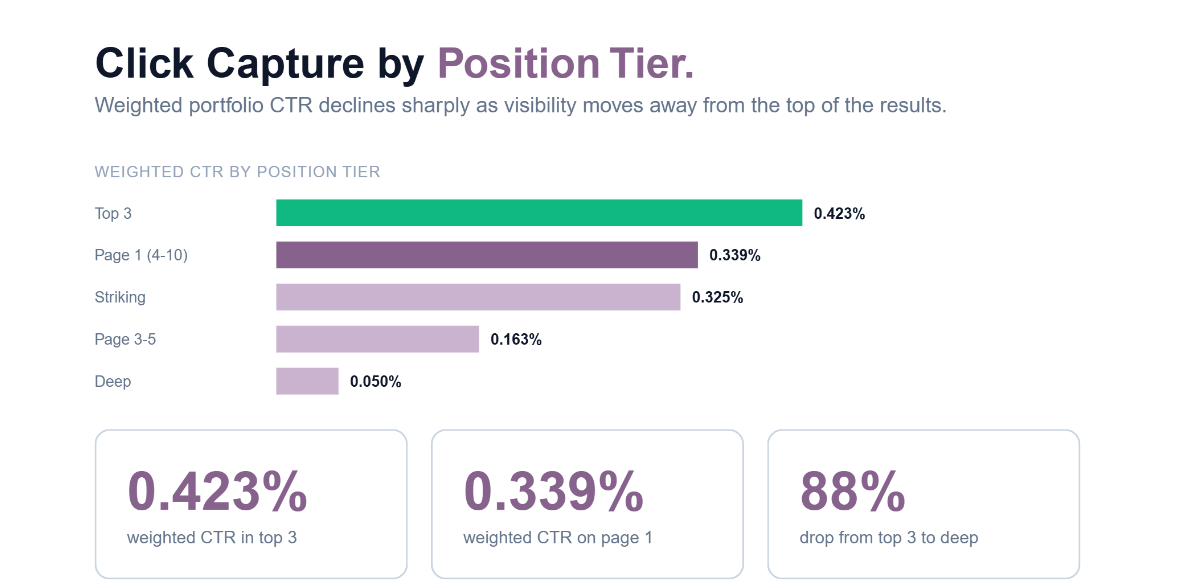

**Label** The label comes from FlyRank’s predefined Position Tier, which categorizes content based on its average search position (Top 3, Page 1, Striking Distance, Page 3–5, or Deep).

**Validation Design:** The finding compares portfolio-level weighted CTR across the position tiers. CTR falls from 0.423% for Top 3 to 0.050% for Deep, supporting the claim that click capture declines at worse ranking positions. However, this is observational evidence, not a causal experiment.

## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [6]:
import pandas as pd
import numpy as np

from huggingface_hub import hf_hub_download

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import gc
import warnings


def run_model_experiment(sample_fraction):

    print(
        f"\n--- Running BEFORE vs AFTER Experiment "
        f"with Sample Fraction: {sample_fraction * 100:.0f}% ---"
    )

    warnings.filterwarnings("ignore")


    # ============================================================
    # 1. DATA LOADING
    # ============================================================

    repo_id = "FlyRank/internship-warehouse"
    file_name = "fact_content_daily_performance_sample.parquet"

    file_path = hf_hub_download(
        repo_id=repo_id,
        filename=file_name,
        repo_type="dataset"
    )


    needed_columns = [

        # Time split
        "report_date",

        # Target creation
        "gsc_clicks",
        "gsc_impressions",
        "gsc_avg_position",

        # Model features
        "ga4_pageviews",
        "ga4_sessions",
        "ga4_users",
        "ga4_engaged_sessions",
        "ga4_total_engagement_sec",

        "sessions_organic",
        "sessions_direct",
        "sessions_referral",
        "sessions_social",
        "sessions_paid",
        "sessions_ai",

        "ai_chatgpt",
        "ai_perplexity",
        "ai_gemini",
        "ai_copilot",
        "ai_claude",
        "ai_meta",
        "ai_other",

        "scroll_events"
    ]


    df = pd.read_parquet(
        file_path,
        columns=needed_columns
    )


    df["report_date"] = pd.to_datetime(
        df["report_date"]
    )


    # ============================================================
    # 2. MEMORY OPTIMIZATION
    # ============================================================

    for col in df.select_dtypes(include=["int64"]).columns:

        df[col] = pd.to_numeric(
            df[col],
            downcast="integer"
        )


    for col in df.select_dtypes(include=["float64"]).columns:

        df[col] = pd.to_numeric(
            df[col],
            downcast="float"
        )


    print(
        f"DataFrame memory after optimization: "
        f"{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB"
    )


    # ============================================================
    # 3. RENAME COLUMNS + CALCULATE CTR
    # ============================================================

    df = df.rename(
        columns={
            "gsc_clicks": "clicks_90d",
            "gsc_impressions": "impressions_90d",
            "gsc_avg_position": "avg_position"
        }
    )


    df["ctr"] = (
        df["clicks_90d"]
        / df["impressions_90d"]
    )


    df["ctr"] = (
        df["ctr"]
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
    )


    # ============================================================
    # 4. HIGH IMPRESSIONS THRESHOLD
    # SAME METHOD AS ORIGINAL CODE
    # ============================================================

    # 90th percentile among NON-ZERO impressions

    non_zero_impressions = df[
        df["impressions_90d"] > 0
    ]["impressions_90d"]


    if not non_zero_impressions.empty:

        high_impressions_threshold = (
            non_zero_impressions.quantile(0.90)
        )

    else:

        high_impressions_threshold = 100


    print(
        f"\nHigh impressions threshold: "
        f"{high_impressions_threshold:.0f}"
    )


    # ============================================================
    # 5. BEFORE RULE
    # ORIGINAL GLOBAL LOW-CTR METHOD
    # ============================================================

    # 25th percentile among NON-ZERO CTR values

    non_zero_ctrs = df[
        df["ctr"] > 0
    ]["ctr"]


    if not non_zero_ctrs.empty:

        low_ctr_threshold = (
            non_zero_ctrs.quantile(0.25)
        )

        if low_ctr_threshold == 0:
            low_ctr_threshold = 0.0001

    else:

        low_ctr_threshold = 0.0001


    print(
        f"BEFORE global low CTR threshold: "
        f"{low_ctr_threshold:.6f}"
    )


    # Original Week-4 rule

    df["refresh_before"] = (

        (df["ctr"] < low_ctr_threshold)

        &

        (
            df["impressions_90d"]
            > high_impressions_threshold
        )

    ).astype("int8")


    # ============================================================
    # 6. AFTER RULE
    # POSITION-TIER-AWARE LOW CTR
    # ============================================================

    # FlyRank position tiers

    df["position_tier"] = pd.cut(

        df["avg_position"],

        bins=[
            -np.inf,
            3,
            10,
            20,
            50,
            np.inf
        ],

        labels=[
            "Top 3",
            "Page 1",
            "Striking Distance",
            "Page 3-5",
            "Deep"
        ]

    )


    # ------------------------------------------------------------
    # SAME LOW-CTR METHOD AS ORIGINAL
    #
    # Original:
    # 25th percentile among non-zero CTRs across ALL rows
    #
    # New:
    # 25th percentile among non-zero CTRs WITHIN EACH position tier
    # ------------------------------------------------------------

    tier_low_ctr_thresholds = {}


    for tier in df["position_tier"].dropna().unique():

        # Select this position tier
        tier_data = df[
            df["position_tier"] == tier
        ]


        # EXACT SAME non-zero filtering as original rule
        non_zero_tier_ctrs = tier_data[
            tier_data["ctr"] > 0
        ]["ctr"]


        # EXACT SAME 25th percentile calculation
        if not non_zero_tier_ctrs.empty:

            tier_threshold = (
                non_zero_tier_ctrs.quantile(0.25)
            )

            if tier_threshold == 0:
                tier_threshold = 0.0001

        else:

            tier_threshold = 0.0001


        tier_low_ctr_thresholds[tier] = tier_threshold


    print("\nAFTER: Low CTR threshold for each position tier:")

    for tier, threshold in tier_low_ctr_thresholds.items():

        print(
            f"{tier}: {threshold:.6f}"
        )


    # Give every row the threshold belonging to its tier

    df["tier_low_ctr_threshold"] = (
        df["position_tier"]
        .map(tier_low_ctr_thresholds)
        .astype(float)
    )


    # New position-aware refresh rule
    #
    # High impressions remains EXACTLY THE SAME.
    # Only low CTR has become position-aware.

    df["refresh_after"] = (

        (
            df["ctr"]
            < df["tier_low_ctr_threshold"]
        )

        &

        (
            df["impressions_90d"]
            > high_impressions_threshold
        )

    ).astype("int8")


    # ============================================================
    # 7. RAW BEFORE / AFTER LABEL COMPARISON
    # ============================================================

    before_count = int(
        df["refresh_before"].sum()
    )

    after_count = int(
        df["refresh_after"].sum()
    )

    changed_count = int(
        (
            df["refresh_before"]
            != df["refresh_after"]
        ).sum()
    )


    print("\n======================================")
    print("REFRESH RULE COMPARISON")
    print("======================================")

    print(
        f"BEFORE refresh candidates: "
        f"{before_count:,}"
    )

    print(
        f"AFTER refresh candidates: "
        f"{after_count:,}"
    )

    print(
        f"Changed refresh decisions: "
        f"{changed_count:,}"
    )


    # ============================================================
    # 8. STRATIFIED SAMPLING
    # ============================================================

    # Stratify on the combination of BEFORE and AFTER labels
    # so both rule outcomes are represented.

    df["comparison_group"] = (
        df["refresh_before"].astype(str)
        + "_"
        + df["refresh_after"].astype(str)
    )


    sampled_parts = []


    for group_name, group_df in df.groupby(
        "comparison_group"
    ):

        sampled_group = group_df.sample(
            frac=sample_fraction,
            random_state=42
        )

        sampled_parts.append(
            sampled_group
        )


    df_sampled = pd.concat(
        sampled_parts,
        ignore_index=True
    )


    print(
        f"\nSampled DataFrame size: "
        f"{len(df_sampled):,} rows "
        f"({sample_fraction * 100:.0f}% of original)"
    )


    del df
    gc.collect()


    # ============================================================
    # 9. FEATURE SELECTION
    # ============================================================

    features = [

        "avg_position",

        "ga4_pageviews",
        "ga4_sessions",
        "ga4_users",
        "ga4_engaged_sessions",
        "ga4_total_engagement_sec",

        "sessions_organic",
        "sessions_direct",
        "sessions_referral",
        "sessions_social",
        "sessions_paid",

        "sessions_ai",

        "ai_chatgpt",
        "ai_perplexity",
        "ai_gemini",
        "ai_copilot",
        "ai_claude",
        "ai_meta",
        "ai_other",

        "scroll_events"
    ]


    # IMPORTANT:
    #
    # Position is now used to construct the AFTER label.
    # To make BEFORE vs AFTER model performance more defensible,
    # remove avg_position from BOTH models.
    #
    # Otherwise AFTER performance could benefit from target leakage.

    comparison_features = [
        feature
        for feature in features
        if feature != "avg_position"
    ]


    print(
        f"\nNumber of comparison features: "
        f"{len(comparison_features)}"
    )


    # ============================================================
    # 10. TIME-AWARE TRAIN / TEST SPLIT
    # ============================================================

    df_sampled = (

        df_sampled
        .sort_values("report_date")
        .reset_index(drop=True)

    )


    unique_dates = (
        df_sampled["report_date"]
        .dropna()
        .unique()
    )


    split_point_idx = int(
        len(unique_dates) * 0.8
    )


    split_date = unique_dates[
        split_point_idx
    ]


    train_df_time = df_sampled[
        df_sampled["report_date"] < split_date
    ].copy()


    test_df_time = df_sampled[
        df_sampled["report_date"] >= split_date
    ].copy()


    print(
        f"\nTrain set date range: "
        f"{train_df_time['report_date'].min()} "
        f"to {train_df_time['report_date'].max()}"
    )


    print(
        f"Test set date range: "
        f"{test_df_time['report_date'].min()} "
        f"to {test_df_time['report_date'].max()}"
    )


    print(
        f"Train set size: {len(train_df_time):,}, "
        f"Test set size: {len(test_df_time):,}"
    )


    del df_sampled
    gc.collect()


    # ============================================================
    # 11. FUNCTION TO TRAIN + EVALUATE ONE RULE
    # ============================================================

    def evaluate_target(
        target_column,
        target_name
    ):

        print(
            f"\n======================================"
        )

        print(
            f"TRAINING MODELS FOR: {target_name}"
        )

        print(
            f"======================================"
        )


        train_clean = train_df_time[
            comparison_features
            + [target_column]
        ].dropna()


        test_clean = test_df_time[
            comparison_features
            + [target_column]
        ].dropna()


        X_train_raw = train_clean[
            comparison_features
        ]


        y_train = train_clean[
            target_column
        ]


        X_test_raw = test_clean[
            comparison_features
        ]


        y_test = test_clean[
            target_column
        ]


        print(
            f"Positive refresh items in training set: "
            f"{int(y_train.sum()):,}"
        )


        print(
            f"Positive refresh items in test set: "
            f"{int(y_test.sum()):,}"
        )


        # ========================================================
        # SCALE
        # ========================================================

        scaler = StandardScaler()


        X_train = scaler.fit_transform(
            X_train_raw
        )


        X_test = scaler.transform(
            X_test_raw
        )


        # ========================================================
        # SMOTE
        # ========================================================

        print("Applying SMOTE...")


        smote = SMOTE(
            random_state=42
        )


        X_train_resampled, y_train_resampled = (
            smote.fit_resample(
                X_train,
                y_train
            )
        )


        # ========================================================
        # MODELS
        # SAME MODELS AS ORIGINAL WEEK 5
        # ========================================================

        models = {

            "Logistic Regression":
                LogisticRegression(
                    random_state=42,
                    solver="liblinear",
                    class_weight="balanced"
                ),

            "Decision Tree":
                DecisionTreeClassifier(
                    random_state=42,
                    class_weight="balanced"
                ),

            "Random Forest":
                RandomForestClassifier(
                    n_estimators=100,
                    random_state=42,
                    n_jobs=1,
                    class_weight="balanced"
                )
        }


        model_results = {}


        # ========================================================
        # TRAIN + EVALUATE
        # ========================================================

        for model_name, model in models.items():

            print(
                f"Training {model_name}..."
            )


            model.fit(
                X_train_resampled,
                y_train_resampled
            )


            y_pred = model.predict(
                X_test
            )


            y_prob = model.predict_proba(
                X_test
            )[:, 1]


            accuracy = accuracy_score(
                y_test,
                y_pred
            )


            precision = precision_score(
                y_test,
                y_pred,
                pos_label=1,
                zero_division=0
            )


            recall = recall_score(
                y_test,
                y_pred,
                pos_label=1,
                zero_division=0
            )


            weighted_f1 = f1_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )


            # Also calculate positive-class F1.
            # This is useful because refresh items are the class
            # we actually care about.

            class1_f1 = f1_score(
                y_test,
                y_pred,
                pos_label=1,
                zero_division=0
            )


            if y_test.nunique() > 1:

                auc = roc_auc_score(
                    y_test,
                    y_prob
                )

            else:

                auc = np.nan


            model_results[model_name] = {

                "Accuracy":
                    accuracy,

                "Precision (Class 1)":
                    precision,

                "Recall (Class 1)":
                    recall,

                "F1 (Class 1)":
                    class1_f1,

                "F1 (Weighted)":
                    weighted_f1,

                "AUC":
                    auc
            }


            del model, y_pred, y_prob
            gc.collect()


        del (
            train_clean,
            test_clean,
            X_train_raw,
            X_test_raw,
            X_train,
            X_test,
            X_train_resampled,
            y_train_resampled,
            y_train,
            y_test,
            scaler,
            smote
        )

        gc.collect()


        return model_results


    # ============================================================
    # 12. RUN ORIGINAL "BEFORE" RULE
    # ============================================================

    before_results = evaluate_target(

        target_column="refresh_before",

        target_name=(
            "BEFORE - GLOBAL LOW CTR"
        )
    )


    # ============================================================
    # 13. RUN POSITION-AWARE "AFTER" RULE
    # ============================================================

    after_results = evaluate_target(

        target_column="refresh_after",

        target_name=(
            "AFTER - POSITION-TIER LOW CTR"
        )
    )


    # ============================================================
    # 14. CREATE BEFORE / AFTER COMPARISON TABLE
    # ============================================================

    comparison_rows = []


    for model_name in before_results.keys():

        for metric_name in before_results[
            model_name
        ].keys():

            before_value = (
                before_results[
                    model_name
                ][metric_name]
            )


            after_value = (
                after_results[
                    model_name
                ][metric_name]
            )


            comparison_rows.append({

                "Model":
                    model_name,

                "Metric":
                    metric_name,

                "Before":
                    before_value,

                "After":
                    after_value,

                "Change":
                    after_value - before_value
            })


    comparison_table = pd.DataFrame(
        comparison_rows
    )


    # ============================================================
    # 15. SUMMARY
    # ============================================================

    print(
        "\n======================================"
    )

    print(
        "FINAL BEFORE / AFTER MODEL COMPARISON"
    )

    print(
        "======================================"
    )


    print(
        comparison_table.round(4).to_string(
            index=False
        )
    )


    print(
        "\n======================================"
    )

    print(
        "REFRESH CANDIDATE COMPARISON"
    )

    print(
        "======================================"
    )


    print(
        f"Before candidates: "
        f"{before_count:,}"
    )


    print(
        f"After candidates: "
        f"{after_count:,}"
    )


    print(
        f"Changed decisions: "
        f"{changed_count:,}"
    )


    # ============================================================
    # 16. CLEAN UP
    # ============================================================

    del train_df_time, test_df_time

    gc.collect()

    warnings.filterwarnings(
        "default"
    )


    # Return everything useful for assignment
    return {

        "before_refresh_count":
            before_count,

        "after_refresh_count":
            after_count,

        "changed_decisions":
            changed_count,

        "global_low_ctr_threshold":
            low_ctr_threshold,

        "high_impressions_threshold":
            high_impressions_threshold,

        "tier_low_ctr_thresholds":
            tier_low_ctr_thresholds,

        "before_results":
            before_results,

        "after_results":
            after_results,

        "comparison_table":
            comparison_table
    }


In [10]:
# ============================================================
# HONEST OVERALL BEFORE vs AFTER COMPARISON
# Majority winner across the SAME metrics and SAME models
# ============================================================
results = run_model_experiment(
    sample_fraction=0.30
)
comparison_table = results["comparison_table"].copy()


# Metrics that will count toward the final winner
# 5 metrics x 3 models = 15 total votes
winner_metrics = [
    "Accuracy",
    "Precision (Class 1)",
    "Recall (Class 1)",
    "F1 (Class 1)",
    "AUC"
]


# Keep only metrics used for deciding the winner
winner_table = comparison_table[
    comparison_table["Metric"].isin(winner_metrics)
].copy()


# Small tolerance to avoid declaring a winner because of
# extremely tiny floating-point differences
tolerance = 1e-6


def declare_metric_winner(row):

    difference = row["After"] - row["Before"]

    if difference > tolerance:
        return "FlyRank Position-Tier Rule"

    elif difference < -tolerance:
        return "Previous Global CTR Rule"

    else:
        return "Tie"


winner_table["Winner"] = winner_table.apply(
    declare_metric_winner,
    axis=1
)


# Round only for DISPLAY
winner_table["Before"] = winner_table["Before"].round(4)
winner_table["After"] = winner_table["After"].round(4)
winner_table["Change"] = winner_table["Change"].round(4)


print("MODEL-BY-MODEL BEFORE vs AFTER COMPARISON")
display(winner_table)


# ============================================================
# COUNT WINS
# ============================================================

previous_wins = (
    winner_table["Winner"]
    == "Previous Global CTR Rule"
).sum()

flyrank_wins = (
    winner_table["Winner"]
    == "FlyRank Position-Tier Rule"
).sum()

ties = (
    winner_table["Winner"]
    == "Tie"
).sum()


winner_summary = pd.DataFrame({

    "Rule": [
        "Previous Global CTR Rule",
        "FlyRank Position-Tier Rule",
        "Tie"
    ],

    "Metrics Won": [
        previous_wins,
        flyrank_wins,
        ties
    ]
})


print("\nWIN SUMMARY")
display(winner_summary)


# ============================================================
# OVERALL WINNER
# ============================================================

if flyrank_wins > previous_wins:

    overall_winner = "FlyRank Position-Tier Rule"

elif previous_wins > flyrank_wins:

    overall_winner = "Previous Global CTR Rule"

else:

    overall_winner = "Tie"


print(
    f"\nOverall Winner: {overall_winner}"
)

print(
    f"Previous Rule wins: {previous_wins} / "
    f"{len(winner_table)} comparisons"
)

print(
    f"FlyRank Rule wins: {flyrank_wins} / "
    f"{len(winner_table)} comparisons"
)

print(
    f"Ties: {ties}"
)


--- Running BEFORE vs AFTER Experiment with Sample Fraction: 30% ---


fact_content_daily_performance_sample.pa(…): reconstructing file:   0%|          |  0.00B /  145MB            

fact_content_daily_performance_sample.pa(…): downloading bytes:           |  0.00B            

DataFrame memory after optimization: 1048.32 MB

High impressions threshold: 113
BEFORE global low CTR threshold: 0.006303

AFTER: Low CTR threshold for each position tier:
Page 1: 0.005102
Page 3-5: 0.011905
Top 3: 0.011834
Striking Distance: 0.010870
Deep: 0.017544

REFRESH RULE COMPARISON
BEFORE refresh candidates: 292,021
AFTER refresh candidates: 285,149
Changed refresh decisions: 32,690

Sampled DataFrame size: 3,508,222 rows (30% of original)

Number of comparison features: 19

Train set date range: 2026-06-01 00:00:00 to 2026-06-24 00:00:00
Test set date range: 2026-06-25 00:00:00 to 2026-06-30 00:00:00
Train set size: 2,868,756, Test set size: 639,466

TRAINING MODELS FOR: BEFORE - GLOBAL LOW CTR
Positive refresh items in training set: 57,035
Positive refresh items in test set: 13,444
Applying SMOTE...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

TRAINING MODELS FOR: AFTER - POSITION-TIER LOW CTR
Positive refresh items in training set: 5

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Metric,Before,After,Change,Winner
0,Logistic Regression,Accuracy,0.9385,0.9390,0.0004,FlyRank Position-Tier Rule
1,Logistic Regression,Precision (Class 1),0.2000,0.1927,-0.0073,Previous Global CTR Rule
2,Logistic Regression,Recall (Class 1),0.4213,0.4092,-0.0121,Previous Global CTR Rule
3,Logistic Regression,F1 (Class 1),0.2712,0.2620,-0.0092,Previous Global CTR Rule
5,Logistic Regression,AUC,0.6825,0.6773,-0.0052,Previous Global CTR Rule
6,Decision Tree,Accuracy,0.9306,0.9338,0.0031,FlyRank Position-Tier Rule
7,Decision Tree,Precision (Class 1),0.1688,0.1703,0.0016,FlyRank Position-Tier Rule
8,Decision Tree,Recall (Class 1),0.3965,0.3881,-0.0084,Previous Global CTR Rule
9,Decision Tree,F1 (Class 1),0.2368,0.2368,-0.0000,Previous Global CTR Rule
11,Decision Tree,AUC,0.6459,0.6440,-0.0019,Previous Global CTR Rule



WIN SUMMARY


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Rule,Metrics Won
0,Previous Global CTR Rule,12
1,FlyRank Position-Tier Rule,3
2,Tie,0



Overall Winner: Previous Global CTR Rule
Previous Rule wins: 12 / 15 comparisons
FlyRank Rule wins: 3 / 15 comparisons
Ties: 0


**Winner**

So from the above metrices we can clearly identify that our previous rule of identifying items for refresh wins with winning 12/15 comparison results. Here the results of my before rule is different than my week 5 model notebook because here the comparison is made by removing avg_position columns from the features to do the honest leakage free comparison between the two rules since the Fly Rank's finding of CTR by position tier has direct dependency on average position column which can lead to feature leakage if I include that column in features. For further working we can consider our previous rule of identifying the refresh items including the column average position.

## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [14]:
# ============================================================
# LEAKAGE AUDIT - WINNING RULE
# ============================================================

import pandas as pd

target = "refresh_before"

# Columns directly used to create the target
target_defining_columns = [
    "ctr",
    "clicks_90d",
    "impressions_90d"
]

# Final features actually used by the trained model
final_features = [
    "avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",
    "scroll_events"
]

print("===== LEAKAGE AUDIT ===时不时")

# ------------------------------------------------------------
# 1. DIRECT TARGET LEAKAGE
# ------------------------------------------------------------

direct_leakage = [
    col
    for col in final_features
    if col in target_defining_columns
]

print("\nTarget-defining columns:")
print(target_defining_columns)

print("\nDirect leakage found:")
print(direct_leakage)

if len(direct_leakage) == 0:
    print(
        "\nPASS: No target-defining columns are present "
        "in the final feature set."
    )
else:
    print(
        "\nFAIL: Direct target leakage detected."
    )


# ------------------------------------------------------------
# 2. TEMPORAL SPLIT CHECK
# ------------------------------------------------------------

# Extracted  dates from the previously run model experiment output as DataFrames are not available
train_max_date = pd.to_datetime("2026-06-24 00:00:00")
test_min_date = pd.to_datetime("2026-06-25 00:00:00")

print("\nLatest train date:", train_max_date)
print("Earliest test date:", test_min_date)

if train_max_date < test_min_date:
    print(
        "PASS: Training data occurs before testing data."
    )
else:
    print(
        "FAIL: Train/test dates overlap."
    )


# ------------------------------------------------------------
# 3. FINAL AUDIT SUMMARY
# ------------------------------------------------------------

print("\n===== FINAL AUDIT SUMMARY ====")

if (
    len(direct_leakage) == 0
    and train_max_date < test_min_date
):
    print(
        "No direct target leakage was found in the final "
        "feature set, and the train/test split is time-safe."
    )
else:
    print(
        "Leakage risk detected. Review the flagged columns "
        "or the train/test time split."
    )


===== LEAKAGE AUDIT ===时不时

Target-defining columns:
['ctr', 'clicks_90d', 'impressions_90d']

Direct leakage found:
[]

PASS: No target-defining columns are present in the final feature set.

Latest train date: 2026-06-24 00:00:00
Earliest test date: 2026-06-25 00:00:00
PASS: Training data occurs before testing data.

===== FINAL AUDIT SUMMARY ====
No direct target leakage was found in the final feature set, and the train/test split is time-safe.


**Interpretation**

So from above results we can interpret that there is no direct leakage found , label defining columns were not used in the final features dataset that were used for prediction, similarly the temporal split check is also done in which dates were taken from previous run model experiement output  confirming that training data occurs before testing data

## 4. Claim rewrite

*Take your own boldest sentence and rewrite it in safe language: observed, measured, directional, decision-support.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


**Honest Claim:**

So by observing the output of above outputs we can interpret that our previous rule of identifying items for potential refresh wins by winning 12 out of 15 comparisons and also pass the leakage audit test. This result supports using the previous rule as a decision-support signal for identifying potential refresh candidates, rather than treating it as proof that a page definitely requires a refresh.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.